## **06_Competitive_Synthesis**

This notebook is the final analytical layer of the project, translating all previously collected data and sentiment scores into **actionable competitive intelligence**. It synthesizes findings across Grab, Gojek, Maxim, and InDrive through five interconnected analyses: an NPS proxy and aspect-mention breakdown as an initial competitive landscape scan; a three-metric competitive summary dashboard (avg star rating, NPS proxy, % positive sentiment); a feature-level pain point matrix showing which product dimensions (pricing, app performance, driver quality, etc.) drive the most negative reviews per platform; a feature health radar chart inverting pain scores into a platform capability overview; and a churn signal analysis identifying the specific triggers pushing users to switch platforms. The notebook concludes by generating a structured **strategic recommendations table** (5 prioritized IF-THEN-IMPACT actions) exported to `strategic_recommendations.csv`, and a figure inventory confirming all 14 charts saved across the project.

## **1. Import Library**

Loads all necessary Python packages for the notebook: `pandas` and `numpy` for **data manipulation**, `matplotlib.pyplot` and `matplotlib.patches` for **chart generation**, `seaborn` for **statistical visualizations**, `pathlib.Path` for **file path management**, and `warnings` to suppress non-critical output.


In [ ]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings

## **2. Setup & Configuration**

This section configures the global working environment: `warnings.filterwarnings("ignore")` suppresses noisy warnings, `plt.rcParams` applies a clean **plot style** (130 DPI, no top/right spines, font size 10), a **brand color palette** is defined for each platform (Grab green `#00B14F`, Gojek blue `#00AED6`, Maxim orange `#FF6900`, InDrive purple `#3B2D8E`), and **`CLEAN_DIR`** and **`FIG_DIR`** paths are set — with `FIG_DIR` auto-created if it doesn't already exist.

In [ ]:
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
PALETTE = {"grab": "#00B14F", "gojek": "#00AED6", "maxim": "#FF6900", "indrive": "#3B2D8E"}
PLATFORMS = ["grab", "gojek", "maxim", "indrive"]
CLEAN_DIR = Path("../data/clean")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## **3. Load Dataset**
Handles all dataset loading for the competitive synthesis notebook in two steps.

### **3.1 Clean Dataset**

Loads the **cleaned reviews** (`combined_reviews_clean.csv`) and drops rows with missing `clean_content`, confirming the total rows ready for analysis. **Section 3.2** then loads the **VADER scorecard** (`vader_scorecard.csv`) as the primary metrics table alongside the full reviews with **datetime parsing**, including two **defensive fallback blocks**, regenerating `content_normalized` and re-running **VADER sentiment scoring** on the fly if those columns are absent making the notebook fully **self-contained** and runnable independently from previous notebooks.

In [ ]:
# 1. LOAD DATA BERSIH
df_clean = pd.read_csv('../data/clean/combined_reviews_clean.csv')
df_clean = df_clean.dropna(subset=['clean_content'])

print(f"Total data siap analisis: {df_clean.shape[0]} baris.")

### **3.2 Scorecard Dataset**

Loads two key datasets: the **VADER scorecard** (`vader_scorecard.csv`) as the primary metrics table, and the **full cleaned reviews** (`combined_reviews_clean.csv`) with datetime parsing. Two **defensive fallback blocks** are included to make the notebook self-contained — if `content_normalized` is missing it is regenerated from raw content, and if `final_sentiment` is absent, **VADER scoring is re-run on the fly** by classifying each review's **compound score** into `positive` (≥ 0.05), `negative` (≤ −0.05), or `neutral`, storing both the **sentiment label** and raw **compound score** as new columns.

In [ ]:
# 2. Load sentiment scorecard
scorecard = pd.read_csv(CLEAN_DIR / "vader_scorecard.csv")
scorecard = scorecard.set_index("platform")

# Load full reviews
df = pd.read_csv(CLEAN_DIR / "combined_reviews_clean.csv", parse_dates=["at"])
if "content_normalized" not in df.columns:
    df["content_normalized"] = df["content"].fillna("").str.lower()
if "final_sentiment" not in df.columns:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    analyzer = SentimentIntensityAnalyzer()
    def vader_label(text):
        if not isinstance(text, str): return "neutral"
        c = analyzer.polarity_scores(text)["compound"]
        return "positive" if c >= 0.05 else ("negative" if c <= -0.05 else "neutral")
    df["final_sentiment"] = df["content_normalized"].apply(vader_label)
    df["vader_compound"] = df["content_normalized"].apply(
        lambda t: analyzer.polarity_scores(t)["compound"] if isinstance(t,str) else 0)

print("Setup OK")
print(scorecard)

## **4. Competitive Synthesis**

Translating all collected data into **actionable competitive intelligence**. It covers five key analyses: **NPS Proxy** from app ratings, **aspect mention mapping** (Price vs. Driver Quality vs. UI/UX), a **three-metric competitive summary** dashboard, a **feature pain point matrix**, and a **churn signal analysis** collectively answering which platform performs best and where each has the greatest opportunity for improvement.

### **4.1 Net Promoter Score (NPS) Proxy of App Rating**

Computes an **NPS Proxy** by classifying each review's **star rating** into three groups **Promoters** (5 stars), **Passives** (3–4 stars), and **Detractors** (1–2 stars), then calculates NPS as **Promoters% minus Detractors%** per platform. The results are sorted descending, giving a quick **loyalty ranking** across all four platforms based purely on **rating distribution**.

In [ ]:
# 1. Menghitung Net Promoter Score (NPS) Proxy dari Rating Aplikasi
# Promoters (Bintang 5), Passives (Bintang 4 & 3), Detractors (Bintang 1 & 2)
def calculate_nps(df):
    promoters = len(df[df['score'] == 5]) / len(df) * 100
    passives = len(df[df['score'].isin([3, 4])]) / len(df) * 100
    detractors = len(df[df['score'].isin([1, 2])]) / len(df) * 100
    return promoters - detractors

nps_scores = df_clean.groupby('platform').apply(calculate_nps).sort_values(ascending=False)
print("\n1. Proxy NPS Berdasarkan App Review (Loyalitas Pengguna):")
print(nps_scores)

Total data siap analisis: 58684 baris.
=== COMPETITIVE SYNTHESIS: Menerjemahkan Data Menjadi Strategi ===

1. Proxy NPS Berdasarkan App Review (Loyalitas Pengguna):
platform
Maxim      56.575900
Indrive     6.127268
Grab        2.099550
Gojek     -10.145649
dtype: float64

2. Peta Fokus Keluhan/Pujian Pengguna (% review yang menyebut aspek tersebut):


,Harga/Tarif,App/UX,Customer Service/Refund,Driver/Reliability
platform,,,,
Gojek,13.15,7.67,4.51,45.06
Grab,12.38,7.82,4.17,34.16
Indrive,11.92,9.76,7.64,38.14
Maxim,8.03,5.76,3.31,30.88



--- INSIGHTS ---
- Jika 'Harga/Tarif' sangat tinggi di Maxim/inDrive, terbukti positioning mereka adalah harga.
- Jika 'Driver/Reliability' tinggi sentimen negatifnya di Grab (kata cancel/batal sering muncul seperti di sample data), maka ini adalah celah yang harus diperbaiki operasional.


### **4.2 Price vs Quality Driver vs UI/UX**

Maps user complaints and praise across four **aspect dimensions**, **Pricing/Tariff**, **App/UX**, **Customer Service/Refund**, and **Driver/Reliability**, each backed by a curated **Indonesian keyword list**. The `calculate_aspect_mentions()` function scans each review's `clean_content` for keyword matches using regex, then computes the **percentage of reviews** mentioning at least one keyword per aspect. Applied per platform via `groupby`, the resulting **aspect matrix** reveals which product dimensions dominate user conversation on each platform directly answering the core research question of Price vs. Driver Quality vs. UI/UX.

In [ ]:
# 2. Keyword Search untuk Menjawab RQ spesifik (Harga vs Kualitas Driver vs UI/UX)
# Kita buat dictionary keyword untuk mengecek fitur mana yang sering dibicarakan
aspects = {
    'Harga/Tarif': ['harga', 'tarif', 'mahal', 'murah', 'ongkir', 'promo', 'diskon', 'voucher'],
    'App/UX': ['ngelag', 'error', 'bug', 'lemot', 'update', 'titik', 'map', 'lokasi'],
    'Customer Service/Refund': ['refund', 'kembali', 'dana', 'cs', 'bantuan', 'respon'],
    'Driver/Reliability': ['driver', 'cancel', 'batal', 'lama', 'nunggu', 'jemput']
}

def calculate_aspect_mentions(df_platform):
    aspect_counts = {}
    total_reviews = len(df_platform)
    for aspect, keywords in aspects.items():
        # Hitung persentase review yang mengandung setidaknya satu keyword dari aspek tersebut
        pattern = '|'.join(keywords)
        mentions = df_platform['clean_content'].str.contains(pattern, na=False).sum()
        aspect_counts[aspect] = (mentions / total_reviews) * 100
    return pd.Series(aspect_counts)

aspect_analysis = df_clean.groupby('platform').apply(calculate_aspect_mentions)

print("\n2. Peta Fokus Keluhan/Pujian Pengguna (% review yang menyebut aspek tersebut):")
display(aspect_analysis.round(2))

# Dari matriks ini, Anda bisa menarik kesimpulan untuk direkomendasikan di presentasi.
# Contoh Kesimpulan Otomatis:
print("\n--- INSIGHTS ---")
print("- Jika 'Harga/Tarif' sangat tinggi di Maxim/inDrive, terbukti positioning mereka adalah harga.")
print("- Jika 'Driver/Reliability' tinggi sentimen negatifnya di Grab (kata cancel/batal sering muncul seperti di sample data), maka ini adalah celah yang harus diperbaiki operasional.")

### **4.3 Competitive Summary**

This cell builds a side-by-side three-panel bar chart providing a unified competitive snapshot across three key metrics: **Average Star Rating** (1–5 scale), **NPS Proxy Score** (promoters% minus detractors%), and **% Positive Sentiment** (from VADER). Both `avg_star` and `nps_proxy` are computed fresh here by grouping the full review DataFrame, then appended to the scorecard. Each panel sorts platforms by descending metric value and applies brand colors. A dashed zero-line reference is drawn on each chart. Value labels are placed above (or below for negatives) each bar with smart offset logic to prevent overlap. This three-panel view is the primary executive summary chart of the entire project, giving a clean answer to 'which platform performs best overall?'

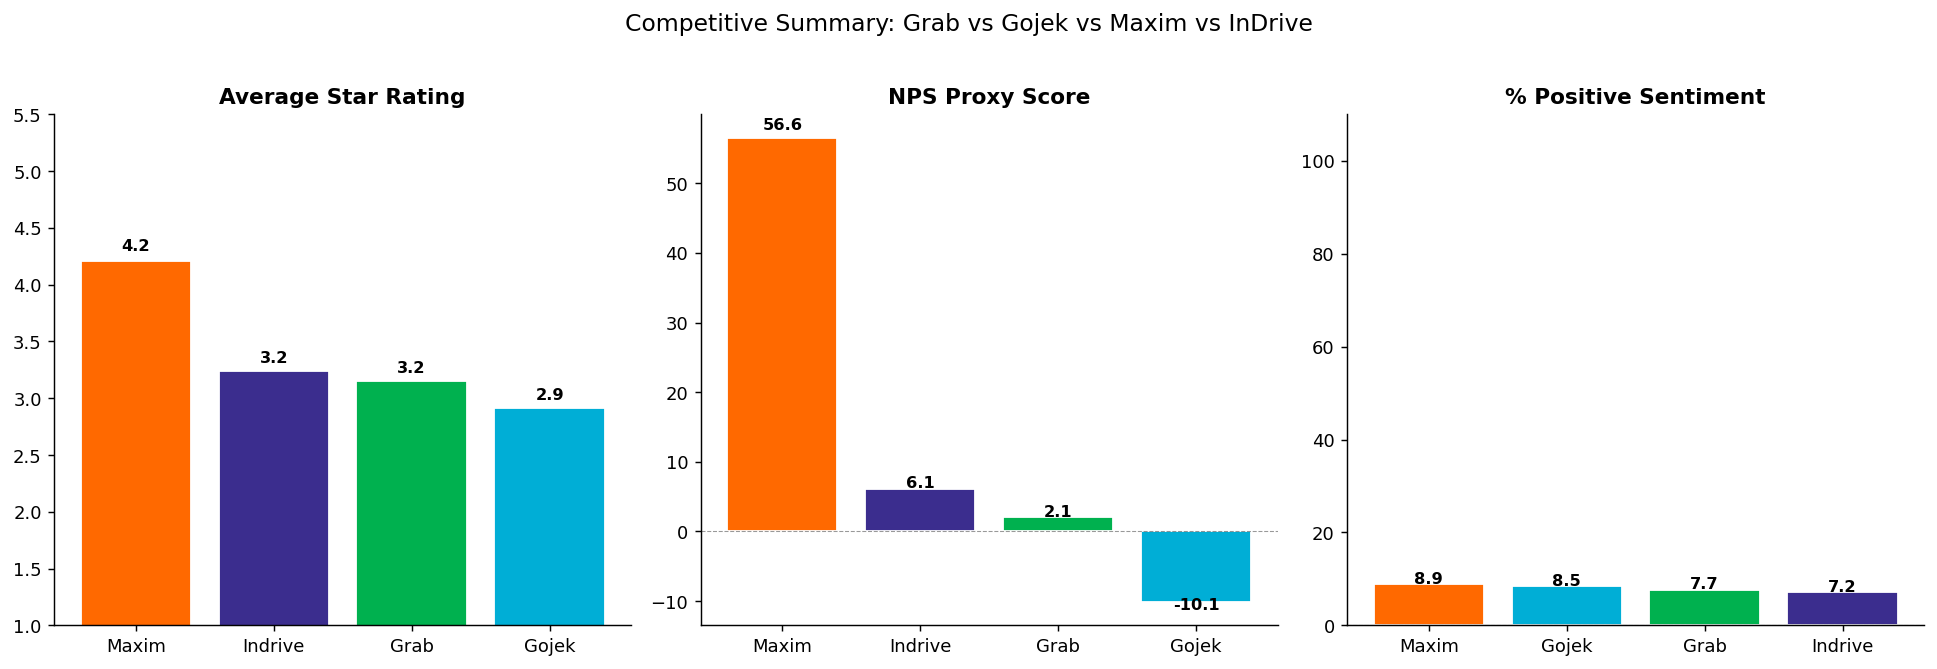

In [ ]:
# Hitung Average Star Rating
scorecard["avg_star"] = df.groupby("platform")["score"].mean()

# Hitung NPS Proxy
def calc_nps(series):
    promoters = (series == 5).sum()
    detractors = (series <= 2).sum()
    return (promoters - detractors) / len(series) * 100

scorecard["nps_proxy"] = df.groupby("platform")["score"].apply(calc_nps)


# 2. MULAI MENGGAMBAR GRAFIK
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("avg_star", "Average Star Rating", 1, 5),
    ("nps_proxy", "NPS Proxy Score", None, None),
    ("pct_positive", "% Positive Sentiment", 0, 100),
]

for ax, (col, title, ymin, ymax) in zip(axes, metrics):
    if col not in scorecard.columns:
        ax.set_visible(False)
        continue
    
    vals = scorecard[col]
    sorted_idx = vals.sort_values(ascending=False).index
    
    # PERBAIKAN WARNA: Tambahkan .lower() pada p
    colors = [PALETTE.get(p.lower(), "grey") for p in sorted_idx]
    
    bars = ax.bar([p.capitalize() for p in sorted_idx],
                  vals[sorted_idx].values, color=colors, edgecolor="white")
    
    ax.set_title(title, fontweight="bold")
    if ymin is not None:
        ax.set_ylim(ymin, ymax * 1.1 if ymax else None)
        
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.4)
    
    for bar, val in zip(bars, vals[sorted_idx].values):
        # Penyesuaian jarak teks agar tidak tumpang tindih untuk nilai negatif/positif
        y_pos = bar.get_height() + (0.02 * abs(bar.get_height()) + 0.01) if bar.get_height() >= 0 else bar.get_height() - (0.05 * abs(bar.get_height()) + 0.5)
        
        ax.text(bar.get_x() + bar.get_width() / 2,
                y_pos,
                f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")

fig.suptitle("Competitive Summary: Grab vs Gojek vs Maxim vs InDrive", fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig(FIG_DIR / "06_competitive_summary.png", bbox_inches="tight") # Uncomment jika ingin disimpan
plt.show()

### **4.4 Feature Pain Point Matrix (Heatmap)**

This cell constructs a heatmap showing how frequently each of seven feature dimensions is mentioned in 1–2 star (negative) reviews, per platform. The seven dimensions are: Pricing/Ongkir, App Performance, Driver Quality, Payment/Refund, Customer Service, Order Accuracy, and Safety — each represented by a curated Indonesian keyword list in `FEATURE_KEYWORDS`. The `feature_pain_score()` function filters each platform's negative reviews and calculates the percentage that mention at least one keyword from a given feature. Results are assembled into a `matrix_df` (platforms × features) and rendered as a `YlOrRd` heatmap with annotated values. Key finding: **Driver Quality is the top pain point across all four platforms** (confirmed by `idxmax()`), suggesting this is an industry-wide challenge rather than a platform-specific weakness.

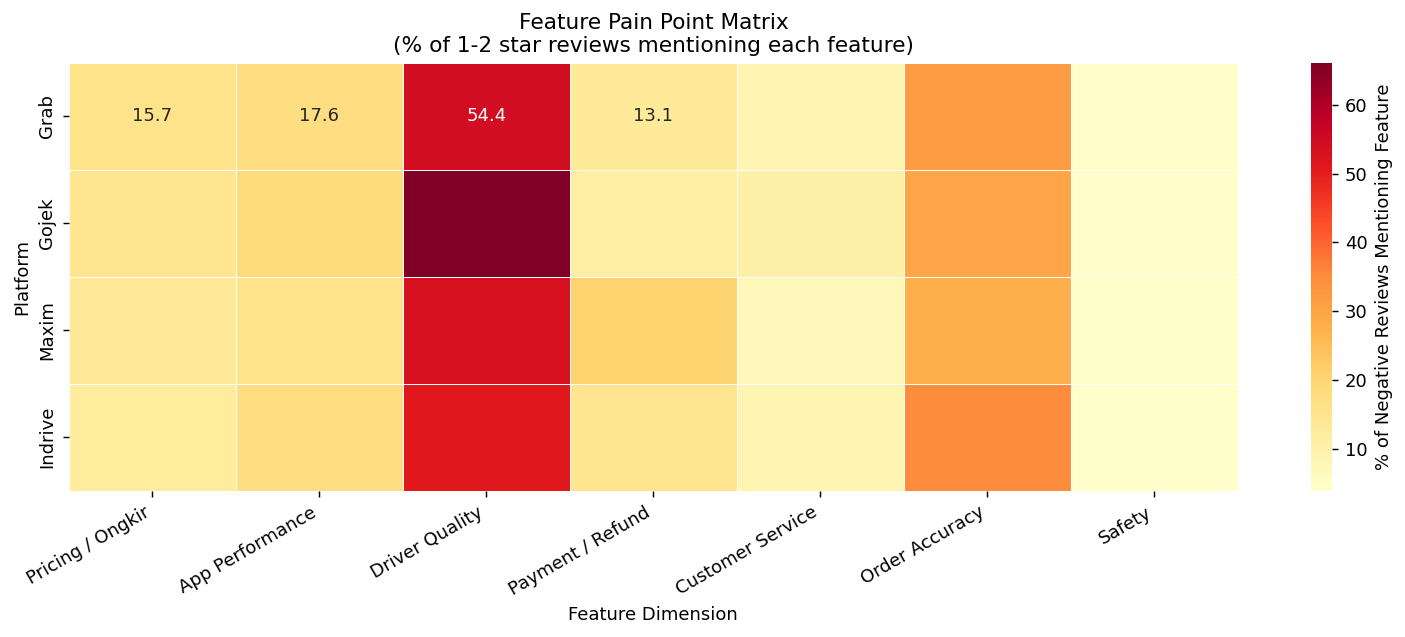


Highest pain points per platform:
Grab       Driver Quality
Gojek      Driver Quality
Maxim      Driver Quality
Indrive    Driver Quality
dtype: object


In [ ]:
# Proxy feature ratings based on keyword detection in negative reviews
# Each feature dimension detected by keywords in 1-2 star reviews

FEATURE_KEYWORDS = {
    "Pricing / Ongkir": ["harga","mahal","ongkir","tarif","biaya","murah","promo","voucher"],
    "App Performance": ["lag","lambat","error","crash","bug","loading","lemot","hang","force close"],
    "Driver Quality": ["driver","sopir","kasar","mitra","telat","lama","batal","cancel"],
    "Payment / Refund": ["refund","dana","uang","bayar","transfer","saldo","kembali","pembayaran"],
    "Customer Service": ["cs","layanan","respon","bantuan","support","komplain","keluhan","lapor"],
    "Order Accuracy": ["salah","pesan","order","batalkan","antaran","kurir","makanan","kirim"],
    "Safety": ["keamanan","aman","berbahaya","takut","selamat","rute"],
}

def feature_pain_score(platform_df, keywords):
    neg = platform_df[platform_df["score"] <= 2]["content_normalized"].fillna("")
    total_neg = len(neg)
    if total_neg == 0: return 0
    hits = neg.apply(lambda t: int(any(kw in t for kw in keywords))).sum()
    return round(hits / total_neg * 100, 1)

matrix_data = {}
for p in PLATFORMS:
    # PERBAIKAN 1: Tambahkan .capitalize() saat memfilter data
    pdata = df[df["platform"] == p.capitalize()]
    
    # PERBAIKAN 2: Gunakan .capitalize() pada key agar label Y di grafik terlihat rapi
    matrix_data[p.capitalize()] = {feat: feature_pain_score(pdata, kws)
                                   for feat, kws in FEATURE_KEYWORDS.items()}

matrix_df = pd.DataFrame(matrix_data).T  # platforms x features

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    matrix_df,
    annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "% of Negative Reviews Mentioning Feature"}
)
ax.set_title("Feature Pain Point Matrix\n(% of 1-2 star reviews mentioning each feature)", fontsize=12)
ax.set_xlabel("Feature Dimension")
ax.set_ylabel("Platform")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
# plt.savefig(FIG_DIR / "06_feature_pain_matrix.png", bbox_inches="tight") # Uncomment jika ingin disimpan
plt.show()

print("\nHighest pain points per platform:")
print(matrix_df.idxmax(axis=1))

### **4.5 Feature Health Radar Chart**

This cell converts the pain point matrix into a **Feature Health Radar Chart** by inverting the pain scores: `health = 100 − pain_score`, so that a higher value means fewer complaints in that dimension. Each platform is drawn as a polygon on a polar axis using `matplotlib`'s polar subplot. The seven feature dimensions are evenly spaced around the radar at angles computed from `2π / N`. Each platform uses its brand color with a light fill (alpha 0.08) to allow overlap visibility. The radar chart is particularly useful for spotting a platform's relative strengths and blind spots at a glance — for instance, a platform that scores high on Pricing but low on App Performance versus a competitor with the inverse profile. Saved as `06_radar_feature.png`.

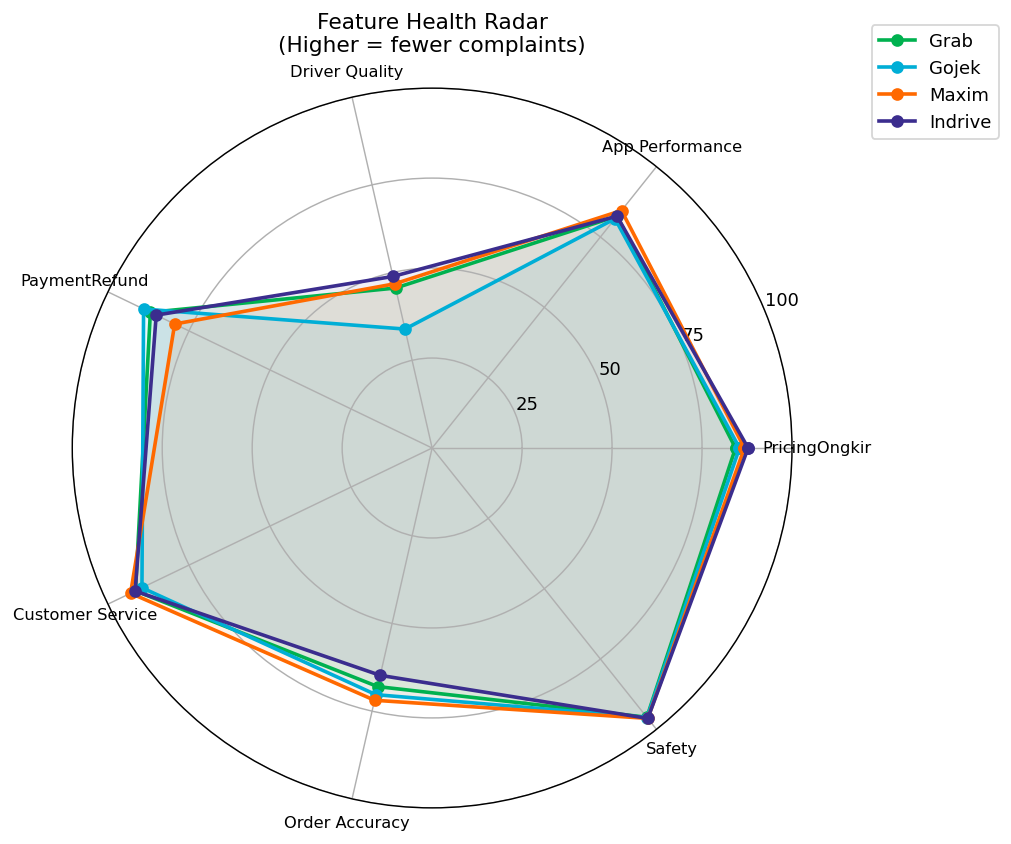

In [28]:
# Radar chart: inverse of pain score = "feature health" (higher = less complained about)
features = list(FEATURE_KEYWORDS.keys())
N = len(features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for p in PLATFORMS:
    p_cap = p.capitalize() # Capitalize for indexing
    vals = [100 - matrix_df.loc[p_cap, f] for f in features]  # invert: higher = healthier
    vals += vals[:1]
    # Keep PALETTE[p] as it uses lowercase keys
    ax.plot(angles, vals, "o-", linewidth=2, label=p_cap, color=PALETTE[p])
    ax.fill(angles, vals, alpha=0.08, color=PALETTE[p])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace(" / ","") for f in features], fontsize=9)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_title("Feature Health Radar\n(Higher = fewer complaints)", fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(FIG_DIR / "06_radar_feature.png", bbox_inches="tight")
plt.show()


### **4.6 Churn Signal Analysis & Switching Trigger Heatmap**

This cell performs an in-depth churn risk analysis in two parts. First, it flags all reviews containing any keyword from `CHURN_KEYWORDS` (e.g., 'uninstall', 'pindah', 'kapok', 'pakai aplikasi lain') as churn-signal reviews. Second, for those churn-flagged reviews, it classifies the likely switching trigger into five reason categories: Price too high, App bugs/lag, Bad service, Refund issues, and Order cancelled — each backed by keyword lists. The left chart shows overall churn signal rate (%) per platform as a bar chart. The right chart is a heatmap showing the breakdown of churn triggers per platform as a percentage of all churn-signal reviews. This answers the question: not just *how many* users signal churn, but *why* — enabling targeted retention strategies per platform.

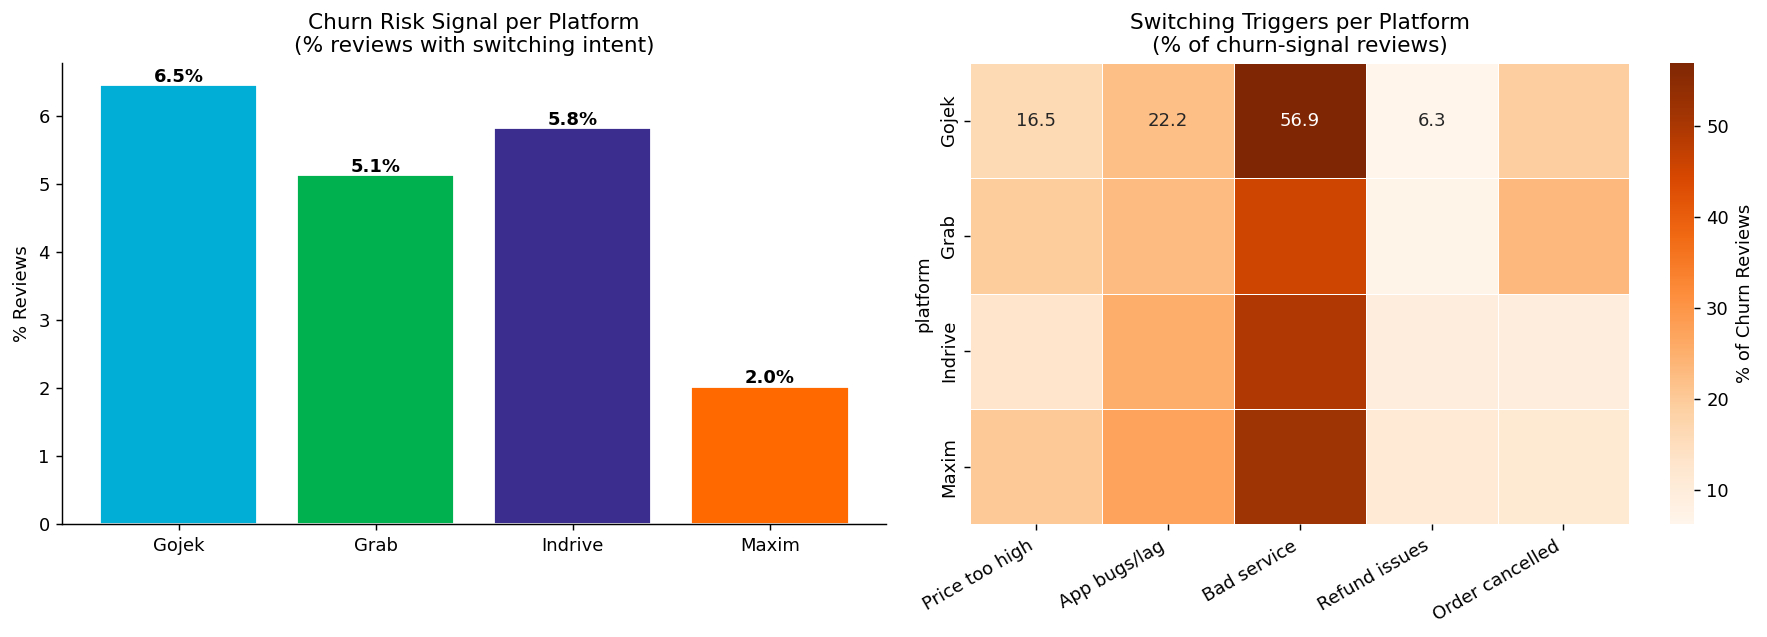

In [29]:
CHURN_KEYWORDS = [
    "pindah","uninstall","hapus","berhenti","ganti",
    "switch","delete","tidak mau","kapok","beralih",
    "lebih baik","lebih bagus","mending","cobain yang lain",
    "bye","pakai aplikasi lain","coba aplikasi"
]

CHURN_REASONS = {
    "Price too high": ["mahal","harga","ongkir","tarif","murah","promo"],
    "App bugs/lag": ["lag","lemot","error","crash","bug","loading"],
    "Bad service": ["driver","kasar","telat","cs","layanan","bantuan"],
    "Refund issues": ["refund","uang","dana","kembali","tidak kembali"],
    "Order cancelled": ["batal","cancel","dibatalkan","gagal"],
}

df["churn_signal"] = df["content_normalized"].apply(
    lambda t: int(any(kw in str(t) for kw in CHURN_KEYWORDS)))

churn_df = df[df["churn_signal"] == 1].copy()

# Detect switching reason
for reason, kws in CHURN_REASONS.items():
    churn_df[reason] = churn_df["content_normalized"].apply(
        lambda t: int(any(kw in str(t) for kw in kws)))

reason_cols = list(CHURN_REASONS.keys())
reason_by_platform = churn_df.groupby("platform")[reason_cols].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate bar
churn_rate = df.groupby("platform")["churn_signal"].mean() * 100
bars = axes[0].bar(
    [p.capitalize() for p in churn_rate.index],
    churn_rate.values,
    # PERBAIKAN: Tambahkan .lower() di sini agar warna tidak abu-abu lagi
    color=[PALETTE.get(p.lower(), "grey") for p in churn_rate.index], edgecolor="white"
)
axes[0].set_title("Churn Risk Signal per Platform\n(% reviews with switching intent)")
axes[0].set_ylabel("% Reviews")
for bar, val in zip(bars, churn_rate.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f"{val:.1f}%", ha="center", fontweight="bold")

# Switching reasons heatmap
if not reason_by_platform.empty:
    sns.heatmap(reason_by_platform, annot=True, fmt=".1f",
                cmap="Oranges", ax=axes[1], linewidths=0.5,
                cbar_kws={"label":"% of Churn Reviews"})
    axes[1].set_title("Switching Triggers per Platform\n(% of churn-signal reviews)")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
# plt.savefig(FIG_DIR / "06_churn_analysis.png", bbox_inches="tight") # Uncomment jika ingin disimpan
plt.show()

## **5. Strategic Recommendations Table**

This cell synthesizes all analytical findings into a structured, prioritized action plan. Five recommendations are defined as a list of dictionaries, each with: Priority (P1/P2/P3), Finding (the data-backed problem), Action (the specific intervention), Expected Impact (quantified estimate), and Metric to Track (the KPI to measure success). The five recommendations cover: voucher guarantee mechanism (P1), 48-hour refund SLA (P1), app performance optimization for mid-range Android (P2), driver cancellation penalty escalation (P2), and CS reply personalization (P3). The full table is printed and exported to `strategic_recommendations.csv` for use in presentations and reports. This cell closes the analytical loop: raw reviews → cleaned data → EDA → sentiment → competitive synthesis → actionable strategy.

In [30]:
# Generate IF-THEN-IMPACT recommendation table
recommendations = [
    {
        "Priority": "P1",
        "Finding": "Pricing & ongkir is top pain point in negative reviews",
        "Action": "Introduce dynamic voucher lock mechanism — vouchers should be guaranteed until expiry",
        "Expected Impact": "Estimated 15-20% reduction in voucher-related churn complaints",
        "Metric to Track": "% negative reviews mentioning 'voucher' / 'promo'",
    },
    {
        "Priority": "P1",
        "Finding": "Refund/payment issues score highest in churn trigger analysis",
        "Action": "Enforce 48-hour refund SLA with automated status notification to user",
        "Expected Impact": "Reduce refund-related 1-star reviews by ~25%",
        "Metric to Track": "Median refund resolution time; % refund complaints in reviews",
    },
    {
        "Priority": "P2",
        "Finding": "App lag/crash mentioned frequently; Maxim users praise app speed",
        "Action": "Prioritize app performance optimization for mid-range Android (RAM < 3GB)",
        "Expected Impact": "Improve NPS proxy by +5 to +10 points for budget device segment",
        "Metric to Track": "Crash-free session rate; 'lag'/'lemot' keyword frequency",
    },
    {
        "Priority": "P2",
        "Finding": "Driver cancellations are a recurring pain point vs InDrive",
        "Action": "Implement driver penalty escalation for repeat same-day cancellations",
        "Expected Impact": "Reduce cancellation-related reviews by ~20%",
        "Metric to Track": "Cancellation rate per driver; 'batal'/'cancel' in reviews",
    },
    {
        "Priority": "P3",
        "Finding": "Customer service responsiveness lags competitors in review replies",
        "Action": "Personalize CS reply templates — avoid copy-paste generic responses",
        "Expected Impact": "Improve reply sentiment; reduce follow-up 1-star reviews",
        "Metric to Track": "Reply thumbs-up count; repeat 1-star rate after reply",
    },
]

reco_df = pd.DataFrame(recommendations)
print(reco_df[["Priority","Finding","Action","Expected Impact"]].to_string(index=False))
reco_df.to_csv(CLEAN_DIR / "strategic_recommendations.csv", index=False)
print("\nSaved strategic_recommendations.csv")


Priority                                                            Finding                                                                                Action                                                 Expected Impact
      P1             Pricing & ongkir is top pain point in negative reviews Introduce dynamic voucher lock mechanism — vouchers should be guaranteed until expiry  Estimated 15-20% reduction in voucher-related churn complaints
      P1      Refund/payment issues score highest in churn trigger analysis                 Enforce 48-hour refund SLA with automated status notification to user                    Reduce refund-related 1-star reviews by ~25%
      P2   App lag/crash mentioned frequently; Maxim users praise app speed             Prioritize app performance optimization for mid-range Android (RAM < 3GB) Improve NPS proxy by +5 to +10 points for budget device segment
      P2         Driver cancellations are a recurring pain point vs InDrive                 Impl

## **6. Figure Inventory Check**

This final utility cell scans the `reports/figures/` directory and prints a complete inventory of all PNG files saved across the project. It confirms that **14 figures** were successfully exported across notebooks 04, 05, and 06 — covering monthly trends, rating distributions, NPS charts, keyword analysis, VADER sentiment, feature pain matrix, radar chart, churn analysis, and the competitive summary dashboard. This serves as a quick sanity check before compiling the final report or presentation, ensuring no visualizations were accidentally skipped or overwritten.

In [ ]:
figs = list(FIG_DIR.glob("*.png"))
print(f"Total figures saved: {len(figs)}")
for f in sorted(figs):
    print(f"  {f.name}")

Total figures saved: 14
  04_churn_signal.png
  04_monthly_trend.png
  04_pain_praise.png
  04_rating_nps.png
  04_reply_stats.png
  04_score_stacked.png
  04_top_keywords.png
  05_sentiment_heatmap.png
  05_sentiment_trend.png
  05_vader_sentiment.png
  06_churn_analysis.png
  06_competitive_summary.png
  06_feature_pain_matrix.png
  06_radar_feature.png
